# SaúdeJá - Classificador de No-show v0.5 (Camila)

Objetivo: prever se um paciente vai faltar à consulta agendada.

Dataset: `data/consultas-historicas.csv` (sintético, ~380 consultas).

Stack: pandas + scikit-learn + LightGBM.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
df = pd.read_csv('data/consultas-historicas.csv')
print(df.shape)
df.head()

(380, 9)


,id_consulta,id_paciente,idade,sexo,especialidade,distancia_km,dias_entre_agendamento_consulta,historico_noshow,no_show
0,1,P1057,52,F,cardiologia,7.4,14,2,0
1,2,P1044,22,F,clinica geral,11.3,65,1,0
2,3,P1214,53,M,dermatologia,0.8,21,2,0
3,4,P1079,61,F,dermatologia,19.3,46,3,0
4,5,P1022,33,M,clinica geral,19.2,71,0,0


## EDA

Dataset pequeno (~400 linhas). Olhar rápido na distribuição.

In [4]:
print(df.describe())
print('\n--- target ---')
print(df['no_show'].value_counts(normalize=True))
print('\n--- especialidade ---')
print(df['especialidade'].value_counts())

       id_consulta       idade  distancia_km  dias_entre_agendamento_consulta  \
count   380.000000  380.000000    380.000000                       380.000000   
mean    190.500000   48.642105     24.487895                        46.215789   
std     109.840794   21.840349     14.815161                        25.602724   
min       1.000000    0.000000      0.600000                         1.000000   
25%      95.750000   34.000000     11.450000                        24.000000   
50%     190.500000   51.000000     24.400000                        44.500000   
75%     285.250000   66.250000     37.550000                        70.000000   
max     380.000000   85.000000     50.000000                        90.000000   

       historico_noshow     no_show  
count        380.000000  380.000000  
mean           1.584211    0.273684  
std            2.025110    0.446437  
min            0.000000    0.000000  
25%            0.000000    0.000000  
50%            1.000000    0.000000  
75% 

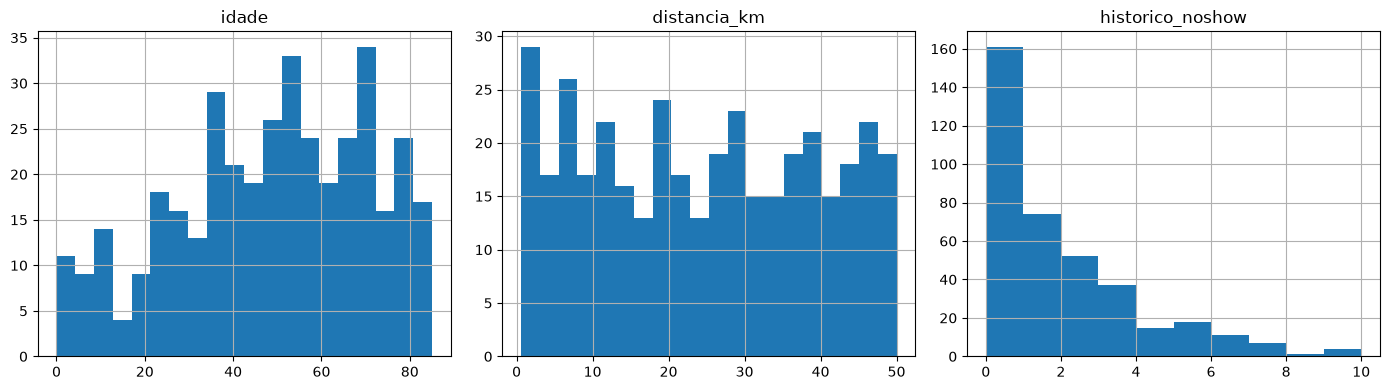

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['idade'].hist(bins=20, ax=axes[0]); axes[0].set_title('idade')
df['distancia_km'].hist(bins=20, ax=axes[1]); axes[1].set_title('distancia_km')
df['historico_noshow'].hist(bins=10, ax=axes[2]); axes[2].set_title('historico_noshow')
plt.tight_layout()
plt.show()

## Pré-processamento

sexo -> 0/1. especialidade -> label encoding (LightGBM lida bem).

In [6]:
df['sexo'] = df['sexo'].map({'F': 0, 'M': 1})

especialidades = sorted(df['especialidade'].unique())
mapa_esp = {e: i for i, e in enumerate(especialidades)}
df['especialidade'] = df['especialidade'].map(mapa_esp)
print('mapa_especialidade:', mapa_esp)

features = ['idade', 'sexo', 'especialidade', 'distancia_km',
            'dias_entre_agendamento_consulta', 'historico_noshow']
X = df[features]
y = df['no_show']
print('X:', X.shape, 'y:', y.shape)

mapa_especialidade: {'cardiologia': 0, 'clinica geral': 1, 'dermatologia': 2, 'ginecologia': 3, 'oftalmologia': 4, 'ortopedia': 5, 'pediatria': 6}
X: (380, 6) y: (380,)


## Treino

Split 80/20 estratificado. LightGBM com hiperparâmetros tunados na mão.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 83, number of negative: 221
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,454446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,273026 -> initscore=-0,979322
[LightGBM] [Info] Start training from score -0,979322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

,max_depth,6
,learning_rate,0.05
,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Acurácia:', model.score(X_test, y_test))
print('ROC-AUC :', roc_auc_score(y_test, y_proba))
print('\n', classification_report(y_test, y_pred, digits=3))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Acurácia: 0.6578947368421053
ROC-AUC : 0.5489177489177488

               precision    recall  f1-score   support

           0      0.730     0.836     0.780        55
           1      0.308     0.190     0.235        21

    accuracy                          0.658        76
   macro avg      0.519     0.513     0.507        76
weighted avg      0.613     0.658     0.629        76

Confusion matrix:
 [[46  9]
 [17  4]]


: 

## Salvar modelo

In [ ]:
joblib.dump({'model': model, 'mapa_especialidade': mapa_esp}, 'model.pkl')
print('modelo salvo em model.pkl')

## Próximos passos (Camila)

- [ ] Transformar isso em API (FastAPI?) — ticket SAUDEJA-241
- [ ] SHAP / feature importance pra liderança médica
- [ ] SMOTE ou class_weight='balanced' pra subir F1 da classe positiva
- [ ] Calibrar threshold com base no custo do SMS vs. perda por no-show
- [ ] Adicionar features de dia-da-semana e horário da consulta
- [ ] Pipeline de re-treino mensal (cron)
- [ ] Testes unitários
- [ ] LGPD: revisar com DPO antes de qualquer dado real